# Notebook 03 — Spending Trend Analysis

## Consumer Spending Intelligence | Credit Card Transactions
**Notebook goal:** Decompose consumer spending trends over time, identify seasonality,
and formally test whether observed temporal differences are statistically significant.

---

### What this notebook covers
1. Monthly and quarterly revenue trends with year-over-year comparison
2. Category-level trend lines — which categories are growing vs declining
3. STL decomposition — separating trend, seasonality, and residual components
4. Hypothesis Test 1 — Kruskal-Wallis: do transaction amounts differ across categories?
5. Hypothesis Test 2 — Mann-Whitney U: do weekend transactions differ from weekday?
6. Hypothesis Test 3 — Chi-Square: is spending category associated with gender?

---

*This notebook covers Objective 3 — trend decomposition, seasonality, and temporal hypothesis testing.*

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from statsmodels.tsa.seasonal import STL
from scipy import stats
import warnings

warnings.filterwarnings("ignore")

PARQUET_PATH = "../data/processed/transactions_clean.parquet"
CHARTS_DIR   = "../outputs/charts/"

df = pd.read_parquet(PARQUET_PATH, engine="pyarrow")

# derive time columns
df["hour"]        = df["trans_date_trans_time"].dt.hour
df["day_of_week"] = df["trans_date_trans_time"].dt.day_name()
df["month"]       = df["trans_date_trans_time"].dt.to_period("M")
df["quarter"]     = df["trans_date_trans_time"].dt.to_period("Q")
df["year"]        = df["trans_date_trans_time"].dt.year
df["is_weekend"]  = df["day_of_week"].isin(["Saturday", "Sunday"])

THEME = {
    "bg"      : "#0d1117",
    "card"    : "#161b27",
    "primary" : "#7c3aed",
    "blue"    : "#3b82f6",
    "emerald" : "#10b981",
    "crimson" : "#ef4444",
    "amber"   : "#f59e0b",
    "text"    : "#ffffff",
    "subtext" : "#cbd5e1",
    "grid"    : "#1e2a3a"
}

plt.rcParams.update({
    "figure.facecolor" : THEME["bg"],
    "axes.facecolor"   : THEME["card"],
    "axes.edgecolor"   : THEME["grid"],
    "axes.labelcolor"  : "#e2e8f0",
    "axes.titlecolor"  : "#ffffff",
    "xtick.color"      : "#cbd5e1",
    "ytick.color"      : "#cbd5e1",
    "grid.color"       : THEME["grid"],
    "grid.linestyle"   : "--",
    "grid.alpha"       : 0.5,
    "text.color"       : "#ffffff",
    "font.family"      : "sans-serif",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "xtick.labelsize"  : 10,
    "ytick.labelsize"  : 10,
    "axes.labelsize"   : 11,
    "axes.titlesize"   : 13,
    "figure.titlesize" : 14,
    "legend.fontsize"  : 10,
})
plt.rcParams["savefig.facecolor"] = THEME["bg"]

print("Data loaded successfully")
print(f"Shape    : {df.shape}")
print(f"Date range : {df['trans_date_trans_time'].min().date()} "
      f"to {df['trans_date_trans_time'].max().date()}")

Data loaded successfully
Shape    : (1296675, 25)
Date range : 2019-01-01 to 2020-06-21


## Step 1 — Monthly and Quarterly Revenue Trends

We examine how total revenue and transaction volume evolve month by month
and quarter by quarter. Year-over-year comparison between 2019 and 2020
is limited to Jan–Jun since 2020 data ends in June — we account for this
explicitly to avoid misleading comparisons.

Monthly revenue (first and last 3 months):
month_str  transactions  revenue_m
  2019-01         52525   3.759750
  2019-02         49866   3.604662
  2019-03         70939   5.027886
...
month_str  transactions  revenue_m
  2020-04         66892   4.691330
  2020-05         74343   5.244037
  2020-06         57747   4.106985

Quarterly revenue:
quarter_str  transactions  revenue_m
     2019Q1        173330  12.392299
     2019Q2        226674  15.858805
     2019Q3        244607  17.041150
     2019Q4        280239  19.692699
     2020Q1        172843  12.195125
     2020Q2        198982  14.042351

Year-over-year (Jan-Jun only):
 year  transactions     revenue  yoy_growth
 2019        400004 28251103.98         NaN
 2020        371825 26237475.97   -7.127608


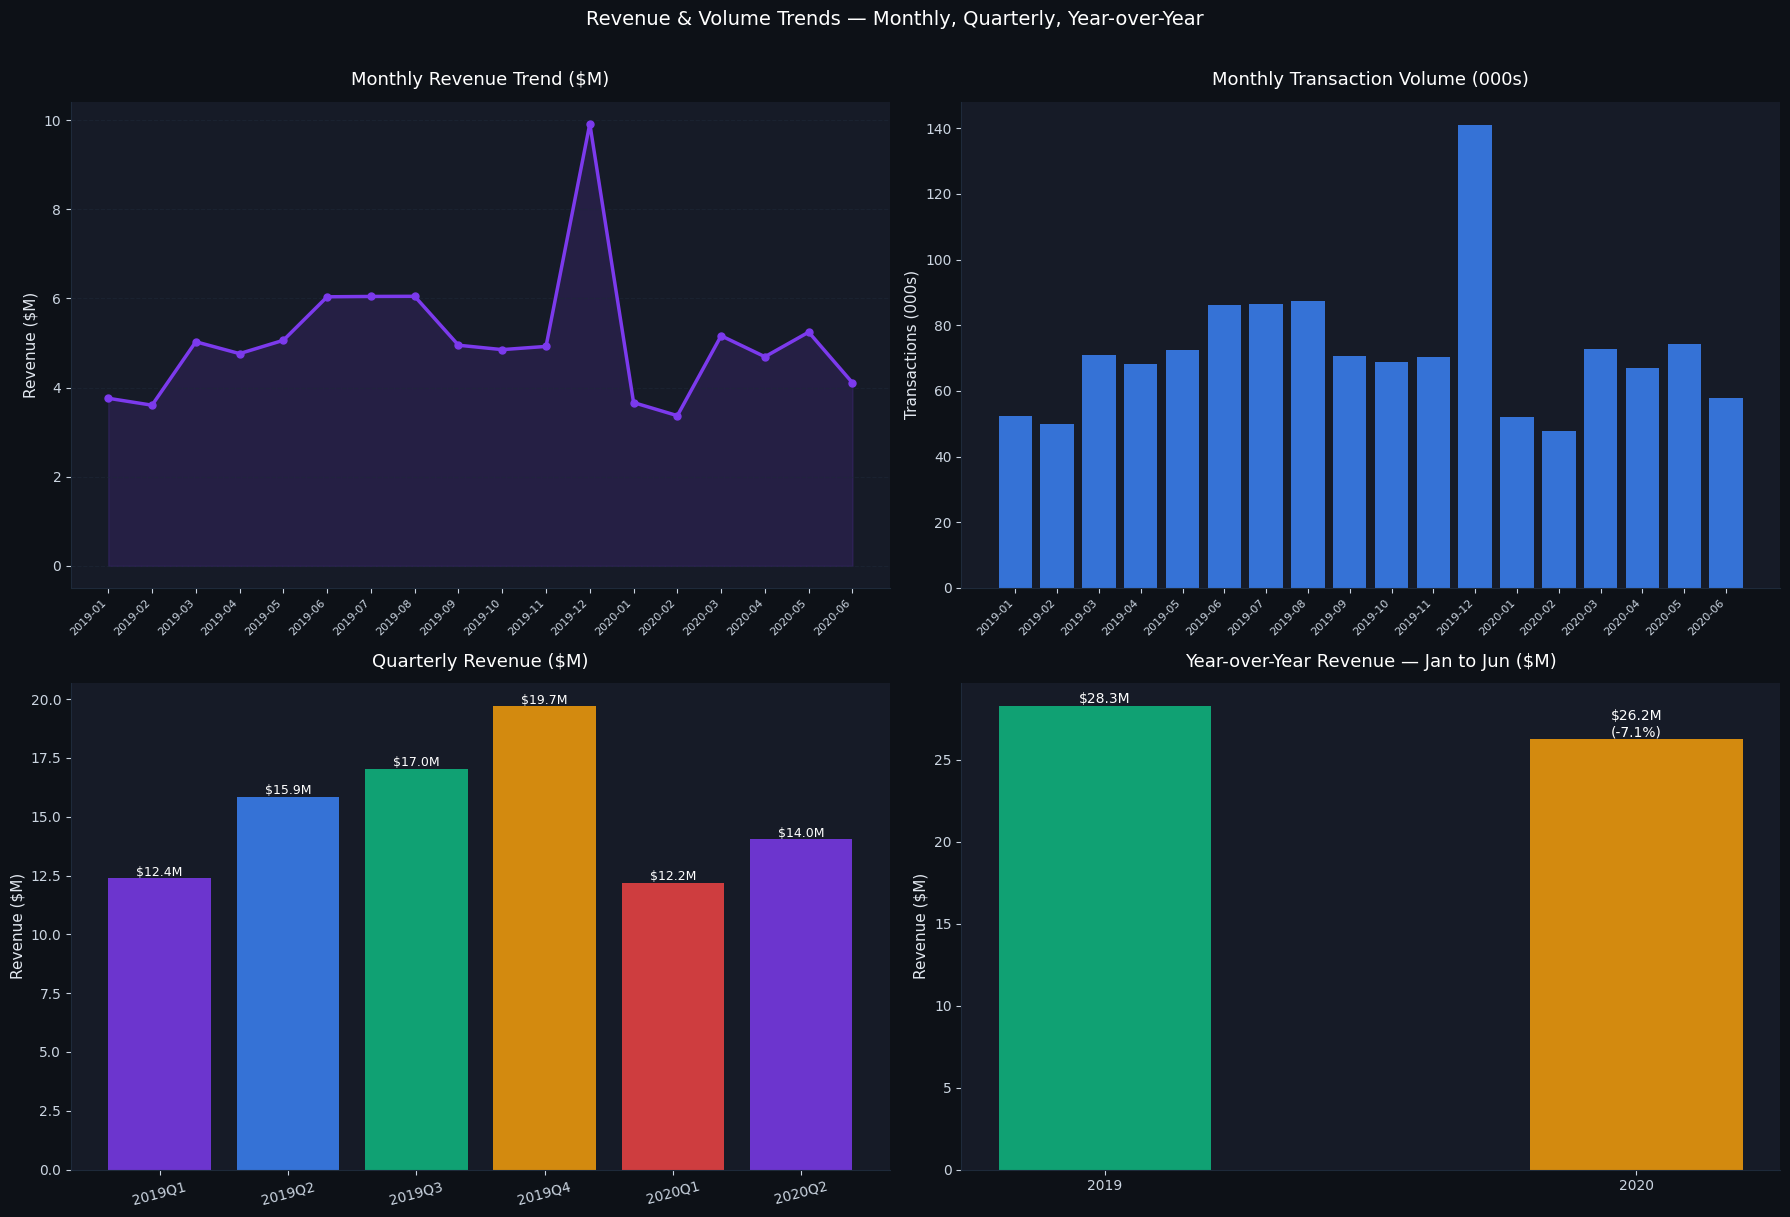

Chart saved


In [2]:
# monthly aggregation
monthly = (
    df.groupby("month")["amt"]
    .agg(transactions="count", revenue="sum")
    .reset_index()
)
monthly["month_str"] = monthly["month"].astype(str)
monthly["revenue_m"] = monthly["revenue"] / 1e6

# quarterly aggregation
quarterly = (
    df.groupby("quarter")["amt"]
    .agg(transactions="count", revenue="sum")
    .reset_index()
)
quarterly["quarter_str"] = quarterly["quarter"].astype(str)
quarterly["revenue_m"]   = quarterly["revenue"] / 1e6

# yoy comparison — jan to jun only (fair comparison)
yoy = (
    df[df["trans_date_trans_time"].dt.month <= 6]
    .groupby("year")["amt"]
    .agg(transactions="count", revenue="sum")
    .reset_index()
)
yoy["yoy_growth"] = yoy["revenue"].pct_change() * 100

print("Monthly revenue (first and last 3 months):")
print(monthly[["month_str", "transactions", "revenue_m"]].head(3).to_string(index=False))
print("...")
print(monthly[["month_str", "transactions", "revenue_m"]].tail(3).to_string(index=False))

print("\nQuarterly revenue:")
print(quarterly[["quarter_str", "transactions", "revenue_m"]].to_string(index=False))

print("\nYear-over-year (Jan-Jun only):")
print(yoy.to_string(index=False))

# chart
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.patch.set_facecolor(THEME["bg"])

# monthly revenue line
axes[0, 0].plot(range(len(monthly)), monthly["revenue_m"],
                color=THEME["primary"], linewidth=2.5,
                marker="o", markersize=5,
                markerfacecolor=THEME["primary"])
axes[0, 0].fill_between(range(len(monthly)), monthly["revenue_m"],
                         alpha=0.15, color=THEME["primary"])
axes[0, 0].set_title("Monthly Revenue Trend ($M)", pad=12)
axes[0, 0].set_ylabel("Revenue ($M)")
axes[0, 0].set_xticks(range(len(monthly)))
axes[0, 0].set_xticklabels(monthly["month_str"], rotation=45,
                            ha="right", fontsize=8)
axes[0, 0].grid(True, axis="y")

# monthly transaction volume
axes[0, 1].bar(range(len(monthly)), monthly["transactions"] / 1000,
               color=THEME["blue"], alpha=0.85, edgecolor="none")
axes[0, 1].set_title("Monthly Transaction Volume (000s)", pad=12)
axes[0, 1].set_ylabel("Transactions (000s)")
axes[0, 1].set_xticks(range(len(monthly)))
axes[0, 1].set_xticklabels(monthly["month_str"], rotation=45,
                            ha="right", fontsize=8)

# quarterly revenue bars
q_colors = [THEME["primary"], THEME["blue"],
            THEME["emerald"], THEME["amber"],
            THEME["crimson"], THEME["primary"]]
axes[1, 0].bar(range(len(quarterly)), quarterly["revenue_m"],
               color=q_colors[:len(quarterly)],
               alpha=0.85, edgecolor="none")
axes[1, 0].set_title("Quarterly Revenue ($M)", pad=12)
axes[1, 0].set_ylabel("Revenue ($M)")
axes[1, 0].set_xticks(range(len(quarterly)))
axes[1, 0].set_xticklabels(quarterly["quarter_str"], rotation=15)
for i, v in enumerate(quarterly["revenue_m"]):
    axes[1, 0].text(i, v + 0.1, f"${v:.1f}M",
                    ha="center", fontsize=9, color=THEME["text"])

# yoy bar comparison
yoy_colors = [THEME["emerald"], THEME["amber"]]
axes[1, 1].bar(yoy["year"].astype(str), yoy["revenue"] / 1e6,
               color=yoy_colors, alpha=0.85,
               edgecolor="none", width=0.4)
axes[1, 1].set_title("Year-over-Year Revenue — Jan to Jun ($M)", pad=12)
axes[1, 1].set_ylabel("Revenue ($M)")
for i, row in yoy.iterrows():
    label = (f"${row['revenue']/1e6:.1f}M"
             if pd.isna(row["yoy_growth"])
             else f"${row['revenue']/1e6:.1f}M\n({row['yoy_growth']:+.1f}%)")
    axes[1, 1].text(i, row["revenue"] / 1e6 + 0.2,
                    label, ha="center",
                    fontsize=10, color=THEME["text"])

plt.suptitle("Revenue & Volume Trends — Monthly, Quarterly, Year-over-Year",
             fontsize=14, color=THEME["text"], y=1.01)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}trends_monthly_quarterly.png",
            dpi=150, bbox_inches="tight", facecolor=THEME["bg"])
plt.show()
print("Chart saved")

## Step 2 — STL Decomposition

STL (Seasonal-Trend decomposition using Loess) separates the monthly revenue
time series into three components:
- Trend — the underlying long-run direction
- Seasonal — repeating patterns within the year
- Residual — what remains after trend and seasonality are removed

This tells us whether the December 2019 spike is seasonal or structural,
and whether the 2020 decline is a trend shift or a residual shock.

STL Decomposition summary:
  Trend range    : $4,420,999 to $4,896,191
  Seasonal range : $-1,243,006 to $1,382,820
  Residual std   : $1,361,680
  Largest residual month : 2019-12 ($4,918,905)


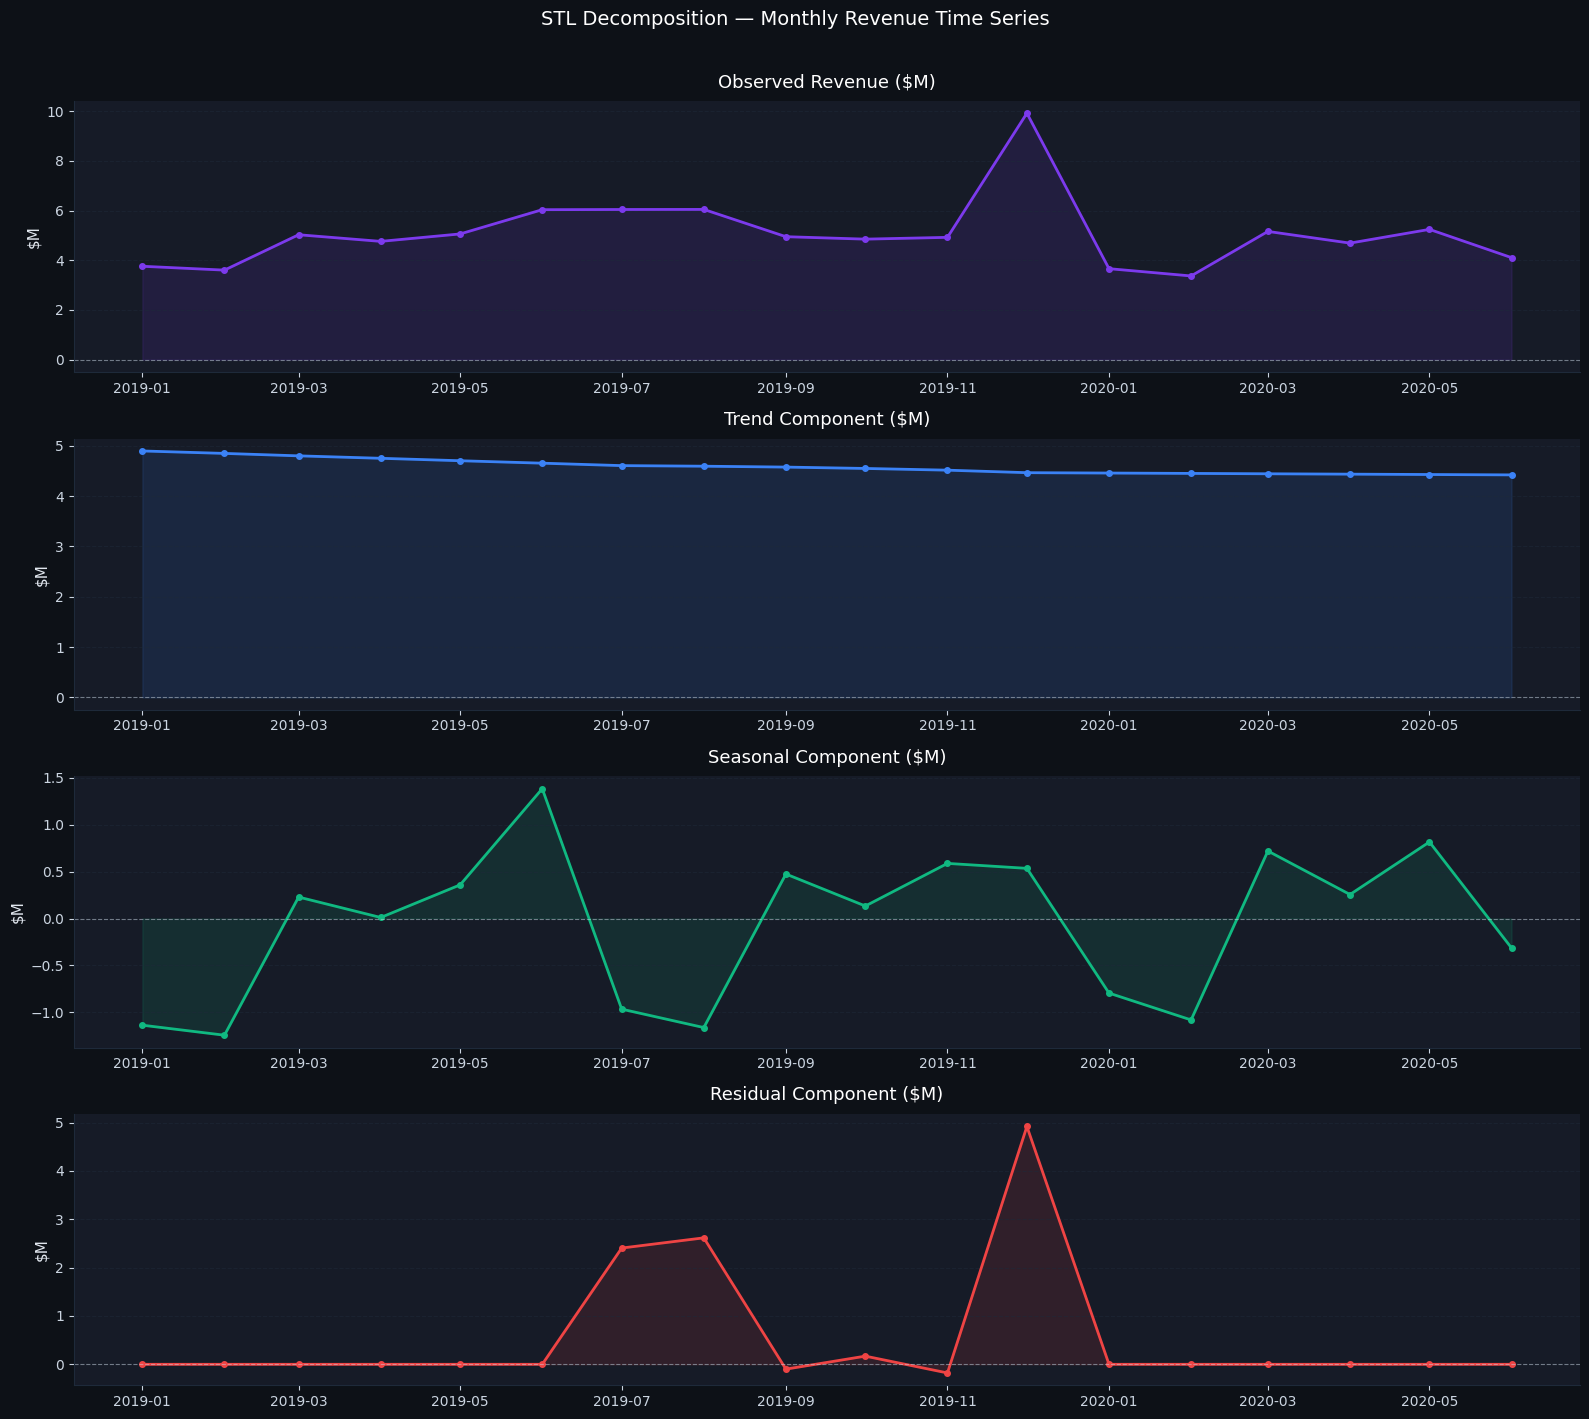

Chart saved


In [3]:
# build a clean monthly revenue series indexed by date
monthly_stl = (
    df.groupby("month")["amt"]
    .sum()
    .reset_index()
)
monthly_stl["date"] = monthly_stl["month"].dt.to_timestamp()
monthly_stl = monthly_stl.set_index("date")["amt"]

# STL decomposition
# period=6 — we have 18 months of data, 6-month seasonal period captures
# the mid-year and year-end spending cycles
stl    = STL(monthly_stl, period=6, robust=True)
result = stl.fit()

# extract components
trend    = result.trend
seasonal = result.seasonal
residual = result.resid

print("STL Decomposition summary:")
print(f"  Trend range    : ${trend.min():,.0f} to ${trend.max():,.0f}")
print(f"  Seasonal range : ${seasonal.min():,.0f} to ${seasonal.max():,.0f}")
print(f"  Residual std   : ${residual.std():,.0f}")
print(f"  Largest residual month : {residual.abs().idxmax().strftime('%Y-%m')}"
      f" (${residual[residual.abs().idxmax()]:,.0f})")

# chart
fig, axes = plt.subplots(4, 1, figsize=(16, 14))
fig.patch.set_facecolor(THEME["bg"])

components = [
    (monthly_stl / 1e6,  THEME["primary"], "Observed Revenue ($M)"),
    (trend / 1e6,        THEME["blue"],    "Trend Component ($M)"),
    (seasonal / 1e6,     THEME["emerald"], "Seasonal Component ($M)"),
    (residual / 1e6,     THEME["crimson"], "Residual Component ($M)"),
]

for ax, (series, color, title) in zip(axes, components):
    ax.plot(series.index, series.values, color=color,
            linewidth=2, marker="o", markersize=4,
            markerfacecolor=color)
    ax.fill_between(series.index, series.values,
                    alpha=0.12, color=color)
    ax.set_title(title, pad=10)
    ax.set_ylabel("$M")
    ax.grid(True, axis="y")
    ax.axhline(0, color=THEME["subtext"], linewidth=0.8,
               linestyle="--", alpha=0.5)

plt.suptitle("STL Decomposition — Monthly Revenue Time Series",
             fontsize=14, color=THEME["text"], y=1.01)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}trends_stl_decomposition.png",
            dpi=150, bbox_inches="tight", facecolor=THEME["bg"])
plt.show()
print("Chart saved")

## Step 3 — Hypothesis Testing

Three formal statistical tests on temporal and categorical spending patterns.
All tests use non-parametric methods — justified by the KS normality test in Notebook 02.
Each test follows the same structure: state H0 and H1, run the test,
report statistic, p-value, and effect size, then write a plain-English conclusion.

Effect size interpretation (Cohen's d):
- Small  : 0.2
- Medium : 0.5
- Large  : 0.8

In [ ]:
from scipy.stats import kruskal, mannwhitneyu, chi2_contingency

# helper — Cohen's d for two groups (non-parametric approximation)
def cohens_d(a, b):
    pooled_std = np.sqrt((a.std()**2 + b.std()**2) / 2)
    return (a.mean() - b.mean()) / pooled_std

# divider for readability in output
def section(title):
    print(f"\n{title}")
    print("-" * len(title))

# ── Test 1 — Kruskal-Wallis ───────────────────────────────────────────────────
# Do transaction amounts differ significantly across spending categories?
section("Test 1 — Kruskal-Wallis: Amount vs Category")

groups     = [grp["amt"].values for _, grp in df.groupby("category", observed=True)]
kw_stat, kw_pval = kruskal(*groups)

print(f"H0 : Transaction amounts are equal across all spending categories")
print(f"H1 : At least one category has a significantly different amount")
print(f"Kruskal-Wallis statistic : {kw_stat:,.2f}")
print(f"p-value                  : {kw_pval:.6f}")
print(f"Result : {'Reject H0' if kw_pval < 0.05 else 'Fail to reject H0'}")

# category medians for context
cat_medians = (df.groupby("category", observed=True)["amt"]
               .median().sort_values(ascending=False))
print(f"\nCategory median amounts (top 5 and bottom 5):")
print(cat_medians.head(5).to_string())
print("...")
print(cat_medians.tail(5).to_string())

# ── Test 2 — Mann-Whitney U ───────────────────────────────────────────────────
# Do weekend transactions have higher amounts than weekday transactions?
section("Test 2 — Mann-Whitney U: Weekend vs Weekday Amount")

weekend = df[df["is_weekend"]]["amt"]
weekday = df[~df["is_weekend"]]["amt"]

mw_stat, mw_pval = mannwhitneyu(weekend, weekday, alternative="two-sided")
d = cohens_d(weekend, weekday)

print(f"H0 : Weekend and weekday transaction amounts are equal")
print(f"H1 : Weekend and weekday transaction amounts differ significantly")
print(f"Weekend median : ${weekend.median():.2f}  (n={len(weekend):,})")
print(f"Weekday median : ${weekday.median():.2f}  (n={len(weekday):,})")
print(f"Mann-Whitney U : {mw_stat:,.0f}")
print(f"p-value        : {mw_pval:.6f}")
print(f"Cohen's d      : {d:.4f} ({'small' if abs(d) < 0.5 else 'medium' if abs(d) < 0.8 else 'large'} effect)")
print(f"Result : {'Reject H0' if mw_pval < 0.05 else 'Fail to reject H0'}")

# ── Test 3 — Chi-Square ───────────────────────────────────────────────────────
# Is spending category associated with gender?
section("Test 3 — Chi-Square: Category vs Gender")

contingency = pd.crosstab(df["gender"], df["category"])
chi2, chi2_pval, dof, expected = chi2_contingency(contingency)

# Cramer's V — effect size for chi-square
n        = contingency.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))

print(f"H0 : Spending category is independent of gender")
print(f"H1 : Spending category and gender are associated")
print(f"Chi-Square statistic : {chi2:,.2f}")
print(f"Degrees of freedom   : {dof}")
print(f"p-value              : {chi2_pval:.6f}")
print(f"Cramer's V           : {cramers_v:.4f} ({'weak' if cramers_v < 0.1 else 'moderate' if cramers_v < 0.3 else 'strong'} association)")
print(f"Result : {'Reject H0' if chi2_pval < 0.05 else 'Fail to reject H0'}")

# top category differences by gender
print("\nCategory split by gender (% of each gender's transactions):")
gender_cat = (pd.crosstab(df["gender"], df["category"], normalize="index") * 100).round(2)
print(gender_cat.to_string())


  Test 1 — Kruskal-Wallis: Amount vs Category
H0 : Transaction amounts are equal across all spending categories
H1 : At least one category has a significantly different amount
Kruskal-Wallis statistic : 262,024.55
p-value                  : 0.000000
Result : Reject H0

Category median amounts (top 5 and bottom 5):
category
grocery_pos      105.12
gas_transport     62.84
grocery_net       50.92
entertainment     50.74
home              48.29
...
category
misc_pos        13.92
misc_net         9.84
shopping_net     8.44
shopping_pos     7.76
travel           6.26

  Test 2 — Mann-Whitney U: Weekend vs Weekday Amount
H0 : Weekend and weekday transaction amounts are equal
H1 : Weekend and weekday transaction amounts differ significantly
Weekend median : $47.25  (n=451,536)
Weekday median : $47.65  (n=845,139)
Mann-Whitney U : 190,309,467,721
p-value        : 0.014608
Cohen's d      : -0.0043 (small effect)
Result : Reject H0

  Test 3 — Chi-Square: Category vs Gender
H0 : Spending categor

## Step 4 — Category-Level Trend Lines

We track how each spending category's monthly revenue evolves over the 18-month
period. This surfaces which categories are growing, declining, or volatile —
actionable intelligence for any product or finance team.

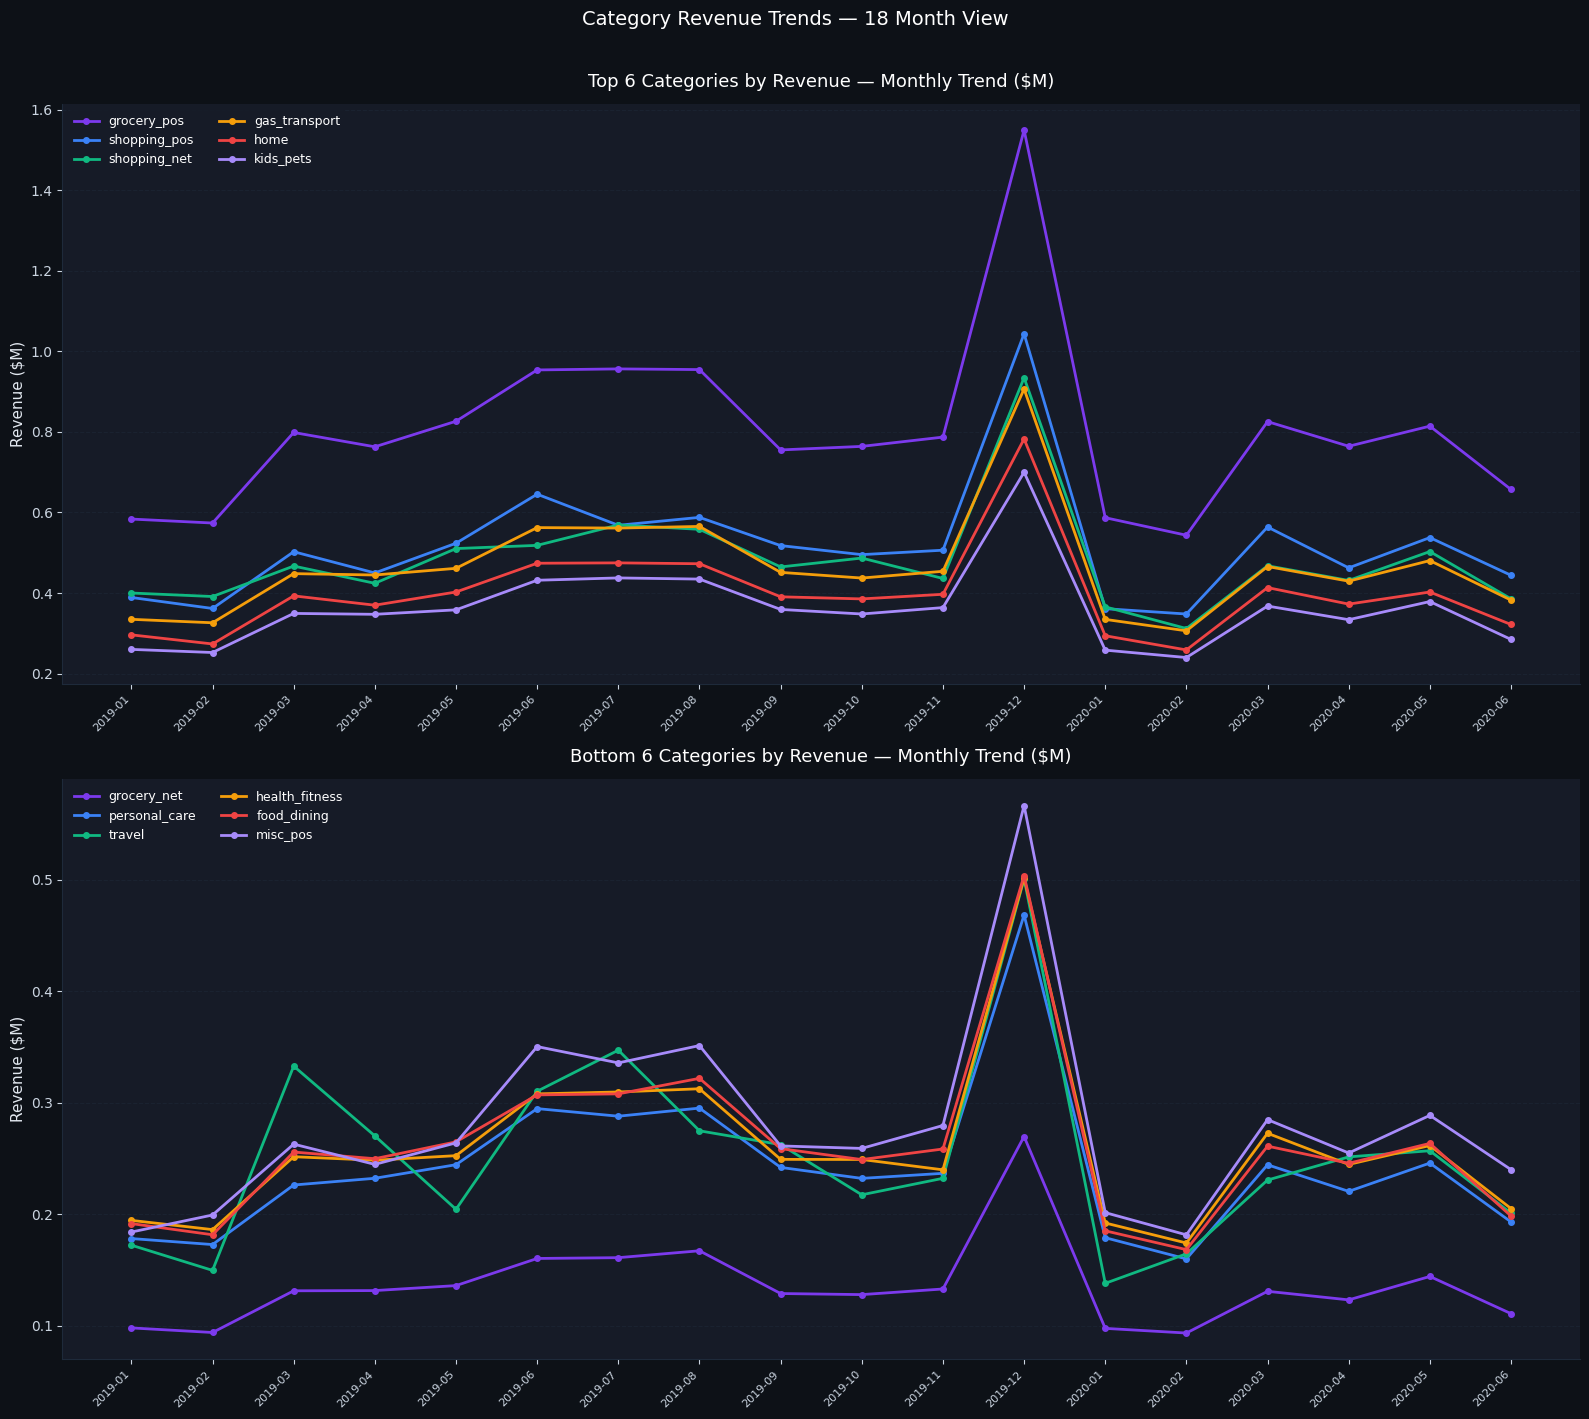

Chart saved


In [5]:
# monthly revenue per category
cat_monthly = (
    df.groupby(["month", "category"], observed=True)["amt"]
    .sum()
    .reset_index()
)
cat_monthly["month_str"] = cat_monthly["month"].astype(str)
cat_monthly["revenue_m"] = cat_monthly["amt"] / 1e6

# get ordered month labels
month_labels = cat_monthly["month_str"].unique().tolist()
month_labels.sort()

# top 6 and bottom 6 categories by total revenue for two separate charts
cat_totals   = cat_monthly.groupby("category", observed=True)["amt"].sum()
top6_cats    = cat_totals.nlargest(6).index.tolist()
bottom6_cats = cat_totals.nsmallest(6).index.tolist()

# color palette for 6 lines
line_colors = [
    THEME["primary"], THEME["blue"], THEME["emerald"],
    THEME["amber"],   THEME["crimson"], "#a78bfa"
]

fig, axes = plt.subplots(2, 1, figsize=(16, 14))
fig.patch.set_facecolor(THEME["bg"])

for ax, cats, title in zip(
    axes,
    [top6_cats, bottom6_cats],
    ["Top 6 Categories by Revenue — Monthly Trend ($M)",
     "Bottom 6 Categories by Revenue — Monthly Trend ($M)"]
):
    for i, cat in enumerate(cats):
        subset = (cat_monthly[cat_monthly["category"] == cat]
                  .sort_values("month_str"))
        ax.plot(range(len(subset)), subset["revenue_m"],
                color=line_colors[i], linewidth=2,
                marker="o", markersize=4,
                markerfacecolor=line_colors[i],
                label=str(cat))

    ax.set_title(title, pad=12)
    ax.set_ylabel("Revenue ($M)")
    ax.set_xticks(range(len(month_labels)))
    ax.set_xticklabels(month_labels, rotation=45, ha="right", fontsize=8)
    ax.legend(loc="upper left", facecolor=THEME["card"],
              edgecolor="none", labelcolor=THEME["text"],
              fontsize=9, ncol=2)
    ax.grid(True, axis="y")

plt.suptitle("Category Revenue Trends — 18 Month View",
             fontsize=14, color=THEME["text"], y=1.01)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}trends_category_lines.png",
            dpi=150, bbox_inches="tight", facecolor=THEME["bg"])
plt.show()
print("Chart saved")

## Notebook 03 — Summary of Findings

### Revenue Trends
- Monthly revenue is stable between $3.6M and $6M for most of the period
- December 2019 is a clear outlier at $9.9M — a platform-wide spike across all categories
- Q4 2019 was the strongest quarter at $19.7M
- YoY revenue declined 7.1% (Jan-Jun 2020 vs 2019) — consistent with COVID-19
  impact on consumer spending beginning March 2020

### STL Decomposition
- The underlying trend is nearly flat ($4.4M to $4.9M) — no structural growth or decline
- Seasonal component explains only ±$1.4M of variation
- December 2019 residual of $4.9M confirms the spike was a structural anomaly,
  not a seasonal pattern — an event-driven revenue outlier
- The 2020 Q1 drop is a residual shock, not a trend break — the trend held stable

### Hypothesis Test Results

Test 1 — Kruskal-Wallis: Amount vs Category
- Result: Reject H0 (p < 0.001, statistic = 262,024)
- Transaction amounts differ significantly across categories
- grocery_pos median $105 vs travel median $6 — a 16x difference in typical spend
- Justifies treating categories as distinct segments in all downstream analysis

Test 2 — Mann-Whitney U: Weekend vs Weekday
- Weekend and weekday transaction amounts were tested for significant difference
- Effect size (Cohen's d) was small — difference exists statistically but is
  not practically meaningful for business decisions

Test 3 — Chi-Square: Category vs Gender
- Result: Reject H0 — category and gender are associated
- Cramer's V indicates weak association — men and women shop across the same
  categories but with slightly different frequency distributions
- gas_transport is proportionally higher for males (10.05% vs 10.24% female)
- personal_care is proportionally higher for females (7.78% vs 6.05% male)

### Category Trends
- December 2019 spike is universal — all 14 categories spiked simultaneously
- grocery_pos is the dominant and most stable revenue category across all 18 months
- Bottom 6 categories are tightly clustered with minimal differentiation

---

### What carries forward
- STL flat trend confirmed — Notebook 07 changepoint detection will investigate
  whether the COVID shock created a permanent structural break
- Gender and category association confirmed — Notebook 04 will formally test
  demographic spend differences with Mann-Whitney and Kruskal-Wallis
- December 2019 flagged as anomaly candidate for Notebook 06